# Semantic Image Segmentation using UNet
## IIT Kharagpur · EE Dept · Algorithms, AI & ML Lab · Spring 2025-26

Running all 4 experiments end-to-end. Dataset downloads automatically on first run (~800 MB).  
Optimised for **Kaggle T4 GPU** with AMP — expected total runtime **~1.5 hrs**.

| Exp | Skip Connections | Loss | Batch Norm | Dropout |
|:---:|:---:|:---:|:---:|:---:|
| 1 | Yes | Cross-Entropy | No | 0.0 |
| 2 | No | Cross-Entropy | No | 0.0 |
| 3 | Yes | CE + Dice | No | 0.0 |
| 4 | Yes | CE + Dice | Yes | 0.3 (bottleneck only) |

> Make sure the GPU accelerator is enabled in Settings → Accelerator → GPU T4 x2.

In [15]:
import torch, sys

print(f"Python   : {sys.version.split()[0]}")
print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    p = torch.cuda.get_device_properties(0)
    print(f"GPU      : {p.name}")
    print(f"VRAM     : {p.total_memory / 1e9:.1f} GB")
else:
    print("No GPU found — enable it in Settings before running")

Python   : 3.12.12
PyTorch  : 2.10.0+cu128
CUDA     : True
GPU      : Tesla T4
VRAM     : 15.6 GB


In [16]:
import os, time, copy, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, datasets
from torch.cuda.amp import autocast, GradScaler
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

# these are all fixed by the spec, don't change them
IMG_SIZE    = 256
BATCH_SIZE  = 16
NUM_WORKERS = 2
EPOCHS      = 30
LR          = 1e-3
NUM_CLASSES = 3
PIN_MEMORY  = torch.cuda.is_available()

# trimap classes: 0=pet interior, 1=background, 2=border outline
CLASS_NAMES  = ["Pet (Foreground)", "Background", "Border"]
CLASS_COLORS = np.array([[220, 80,  60 ],
                          [60,  130, 220],
                          [255, 220, 40 ]])

# kaggle working dir for all outputs
OUT_DIR = "/kaggle/working"
os.makedirs(OUT_DIR, exist_ok=True)

print(f"Training on: {DEVICE}")

Training on: cuda


## Dataset

Oxford-IIIT Pet — 7349 images, 37 cat/dog breeds, 3-class trimaps.  
80/20 train/val split from the trainval set; the test split is held out.

In [17]:
IMG_TRANSFORM = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

class OxfordPetSeg(Dataset):
    def __init__(self, split="trainval", img_transform=None):
        self.base = datasets.OxfordIIITPet(
            root=os.path.join(OUT_DIR, "data"),
            split=split,
            target_types="segmentation",
            download=True,
        )
        self.img_transform = img_transform

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img, mask = self.base[idx]
        if self.img_transform:
            img = self.img_transform(img)
        mask = mask.resize((IMG_SIZE, IMG_SIZE), Image.NEAREST)
        mask = torch.as_tensor(np.array(mask, dtype=np.int64)) - 1
        mask = mask.clamp(0, NUM_CLASSES - 1)
        return img, mask


full_trainval = OxfordPetSeg("trainval", IMG_TRANSFORM)
test_ds       = OxfordPetSeg("test",     IMG_TRANSFORM)

n_train = int(0.8 * len(full_trainval))
n_val   = len(full_trainval) - n_train
train_ds, val_ds = random_split(
    full_trainval, [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)

def make_loader(ds, shuffle=True):
    return DataLoader(
        ds, batch_size=BATCH_SIZE, shuffle=shuffle,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0),
        prefetch_factor=2 if NUM_WORKERS > 0 else None,
        drop_last=False,
    )

train_loader = make_loader(train_ds, shuffle=True)
val_loader   = make_loader(val_ds,   shuffle=False)
test_loader  = make_loader(test_ds,  shuffle=False)

print(f"Train: {len(train_ds)}  |  Val: {len(val_ds)}  |  Test: {len(test_ds)}")
print(f"Batches per epoch — train: {len(train_loader)}, val: {len(val_loader)}")

Train: 2944  |  Val: 736  |  Test: 3669
Batches per epoch — train: 184, val: 46


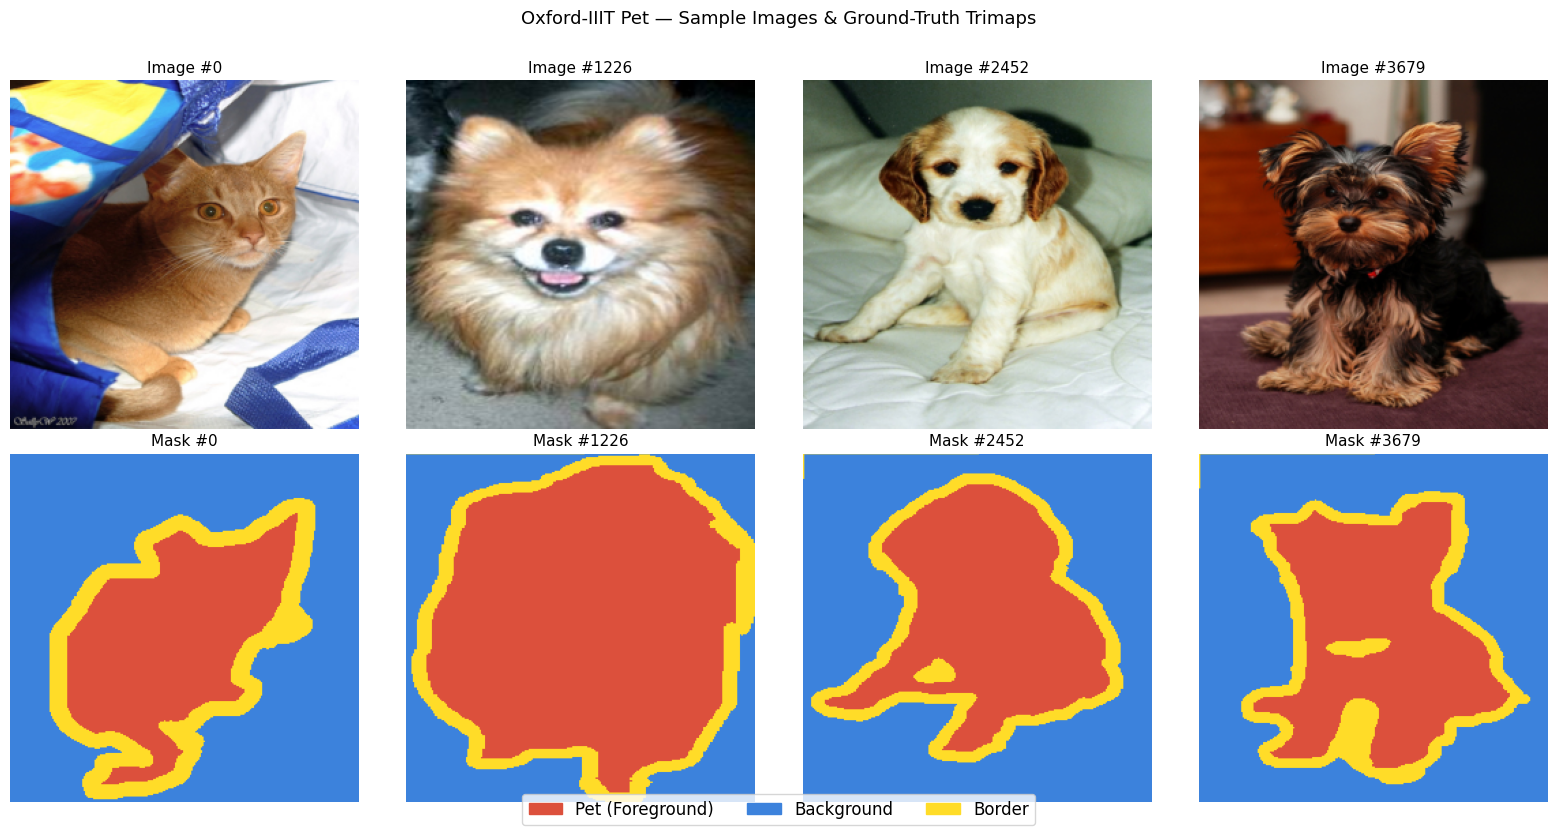

In [18]:
def decode_mask(mask_tensor):
    return CLASS_COLORS[mask_tensor.numpy()].astype(np.uint8)

def unnorm(img_tensor):
    return (img_tensor.permute(1, 2, 0).numpy() * 0.5 + 0.5).clip(0, 1)

NUM_SHOW = 4
fig, axes = plt.subplots(2, NUM_SHOW, figsize=(4 * NUM_SHOW, 8))
indices = np.linspace(0, len(full_trainval) - 1, NUM_SHOW, dtype=int)

for col, idx in enumerate(indices):
    img, mask = full_trainval[idx]
    axes[0, col].imshow(unnorm(img))
    axes[0, col].set_title(f"Image #{idx}", fontsize=11)
    axes[1, col].imshow(decode_mask(mask))
    axes[1, col].set_title(f"Mask #{idx}", fontsize=11)
    for row in range(2):
        axes[row, col].axis("off")

patches = [mpatches.Patch(color=CLASS_COLORS[c]/255, label=CLASS_NAMES[c])
           for c in range(NUM_CLASSES)]
fig.legend(handles=patches, loc="lower center", ncol=3, fontsize=12,
           bbox_to_anchor=(0.5, -0.02))
plt.suptitle("Oxford-IIIT Pet — Sample Images & Ground-Truth Trimaps", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/sample_data.png", dpi=120, bbox_inches="tight")
plt.show()

## Model Architecture

In [19]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch, use_bn=False, drop_p=0.0):
        super().__init__()
        bias = not use_bn  # when BN is on, bias gets absorbed anyway
        layers = [
            nn.Conv2d(in_ch,  out_ch, kernel_size=3, padding=1, bias=bias),
            nn.BatchNorm2d(out_ch) if use_bn else nn.Identity(),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=bias),
            nn.BatchNorm2d(out_ch) if use_bn else nn.Identity(),
            nn.ReLU(inplace=True),
        ]
        if drop_p > 0.0:
            layers.append(nn.Dropout(drop_p))
        self.conv = nn.Sequential(*layers)

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=3, features=[64, 128, 256, 512],
                 use_skip=True, use_bn=False, bottleneck_drop=0.0):
        super().__init__()
        self.use_skip = use_skip

        # encoder path
        self.encoders = nn.ModuleList()
        self.pools    = nn.ModuleList()
        ch = in_channels
        for f in features:
            self.encoders.append(DoubleConv(ch, f, use_bn=use_bn))
            self.pools.append(nn.MaxPool2d(kernel_size=2, stride=2))
            ch = f

        # 1024-channel bottleneck
        bottleneck_ch = features[-1] * 2
        self.bottleneck = DoubleConv(features[-1], bottleneck_ch,
                                     use_bn=use_bn, drop_p=bottleneck_drop)

        # decoder path
        self.upconvs  = nn.ModuleList()
        self.decoders = nn.ModuleList()
        ch = bottleneck_ch
        for f in reversed(features):
            self.upconvs.append(nn.ConvTranspose2d(ch, f, kernel_size=2, stride=2))
            dec_in = f * 2 if use_skip else f
            self.decoders.append(DoubleConv(dec_in, f, use_bn=use_bn))
            ch = f

        self.final_conv = nn.Conv2d(features[0], num_classes, kernel_size=1)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        skips = []
        for enc, pool in zip(self.encoders, self.pools):
            x = enc(x)
            skips.append(x)
            x = pool(x)

        x = self.bottleneck(x)

        for i, (up, dec) in enumerate(zip(self.upconvs, self.decoders)):
            x = up(x)
            if self.use_skip:
                skip = skips[-(i + 1)]
                if x.shape[2:] != skip.shape[2:]:
                    x = F.interpolate(x, size=skip.shape[2:], mode="bilinear", align_corners=False)
                x = torch.cat([skip, x], dim=1)
            x = dec(x)

        return self.final_conv(x)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# quick sanity check before training anything
_m = UNet().to(DEVICE)
with torch.no_grad():
    _y = _m(torch.randn(2, 3, IMG_SIZE, IMG_SIZE, device=DEVICE))
print(f"Output shape : {tuple(_y.shape)}  (expected (2, {NUM_CLASSES}, {IMG_SIZE}, {IMG_SIZE}))")
print(f"Baseline params : {count_params(_m):,}")
del _m, _y

Output shape : (2, 3, 256, 256)  (expected (2, 3, 256, 256))
Baseline params : 31,031,875


## Loss Functions & Metrics

In [20]:
ce_criterion = nn.CrossEntropyLoss()


class DiceLoss(nn.Module):
    # soft multi-class dice — particularly helpful for the minority border class
    def __init__(self, eps=1e-6):
        super().__init__()
        self.eps = eps

    def forward(self, logits, targets):
        probs = torch.softmax(logits, dim=1)
        one_hot = torch.zeros_like(probs)
        one_hot.scatter_(1, targets.unsqueeze(1), 1.0)
        dims = (0, 2, 3)
        inter  = (probs * one_hot).sum(dims)
        denom  = probs.sum(dims) + one_hot.sum(dims)
        dice_c = (2.0 * inter + self.eps) / (denom + self.eps)
        return 1.0 - dice_c.mean()

dice_criterion = DiceLoss()


def get_loss_fn(use_dice):
    if use_dice:
        return lambda pred, tgt: ce_criterion(pred, tgt) + dice_criterion(pred, tgt)
    return lambda pred, tgt: ce_criterion(pred, tgt)


@torch.no_grad()
def compute_metrics(model, loader):
    # accumulate TP/FP/FN globally rather than batch-averaging (more accurate)
    model.eval()
    tp = torch.zeros(NUM_CLASSES, dtype=torch.float64)
    fp = torch.zeros(NUM_CLASSES, dtype=torch.float64)
    fn = torch.zeros(NUM_CLASSES, dtype=torch.float64)
    eps = 1e-6

    for imgs, masks in loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        with autocast():
            preds = model(imgs).argmax(dim=1).cpu()
        masks = masks.cpu()
        for c in range(NUM_CLASSES):
            pc = (preds == c)
            tc = (masks == c)
            tp[c] += (pc &  tc).sum()
            fp[c] += (pc & ~tc).sum()
            fn[c] += (~pc & tc).sum()

    iou_pc  = tp / (tp + fp + fn + eps)
    dice_pc = 2 * tp / (2 * tp + fp + fn + eps)
    return iou_pc.mean().item(), dice_pc.mean().item(), iou_pc.numpy(), dice_pc.numpy()

print("loss functions and metrics ready")

loss functions and metrics ready


## Training Loop

One function handles all four experiments — configs are passed in as a dict.

In [21]:
EXPERIMENT_CONFIGS = [
    {
        "name"            : "Exp 1 — Baseline UNet (CE Loss)",
        "use_skip"        : True,
        "use_bn"          : False,
        "bottleneck_drop" : 0.0,
        "use_dice"        : False,
    },
    {
        "name"            : "Exp 2 — No Skip Connections (Ablation)",
        "use_skip"        : False,
        "use_bn"          : False,
        "bottleneck_drop" : 0.0,
        "use_dice"        : False,
    },
    {
        "name"            : "Exp 3 — CE + Dice Loss",
        "use_skip"        : True,
        "use_bn"          : False,
        "bottleneck_drop" : 0.0,
        "use_dice"        : True,
    },
    {
        "name"            : "Exp 4 — BN + Dropout (Best Architecture)",
        "use_skip"        : True,
        "use_bn"          : True,
        "bottleneck_drop" : 0.3,
        "use_dice"        : True,
    },
]

RESULTS = {}


def run_experiment(cfg, exp_idx):
    print(f"\n{'='*65}")
    print(f"  {cfg['name']}")
    print(f"{'='*65}")

    model = UNet(
        in_channels=3, num_classes=NUM_CLASSES, features=[64, 128, 256, 512],
        use_skip=cfg["use_skip"], use_bn=cfg["use_bn"],
        bottleneck_drop=cfg["bottleneck_drop"],
    ).to(DEVICE)

    n_params = count_params(model)
    loss_fn   = get_loss_fn(cfg["use_dice"])
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scaler    = GradScaler()
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=3, factor=0.5, min_lr=1e-6   # verbose= removed (deprecated in PyTorch 2.4+)
    )

    print(f"  Trainable params: {n_params:,}")

    train_losses, val_losses = [], []
    best_val   = float("inf")
    best_state = None
    no_improve = 0
    PATIENCE   = 7

    t_start = time.time()

    for epoch in range(1, EPOCHS + 1):
        t_ep = time.time()

        model.train()
        running = 0.0
        pbar = tqdm(train_loader, desc=f"  Ep {epoch:02d}/{EPOCHS}", leave=False, ncols=80)
        for imgs, masks in pbar:
            imgs  = imgs.to(DEVICE, non_blocking=True)
            masks = masks.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with autocast():
                loss = loss_fn(model(imgs), masks)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            running += loss.item()
            pbar.set_postfix({"loss": f"{loss.item():.4f}"})
        train_loss = running / len(train_loader)

        model.eval()
        v_total = 0.0
        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs  = imgs.to(DEVICE, non_blocking=True)
                masks = masks.to(DEVICE, non_blocking=True)
                with autocast():
                    v_total += loss_fn(model(imgs), masks).item()
        val_loss = v_total / len(val_loader)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        scheduler.step(val_loss)

        cur_lr  = optimizer.param_groups[0]["lr"]
        elapsed = time.time() - t_ep
        print(f"  ep {epoch:02d}/{EPOCHS}  train={train_loss:.4f}  val={val_loss:.4f}  "
              f"lr={cur_lr:.1e}  {elapsed:.0f}s")

        if epoch % 5 == 0:
            ckpt_path = f"{OUT_DIR}/exp{exp_idx}_ep{epoch:02d}.pth"
            torch.save({"epoch": epoch, "state_dict": model.state_dict(),
                        "val_loss": val_loss}, ckpt_path)

        if val_loss < best_val:
            best_val   = val_loss
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                print(f"  [early stop] no improvement for {PATIENCE} epochs, stopping at ep {epoch}")
                break

    total_min = (time.time() - t_start) / 60
    print(f"  Finished in {total_min:.1f} min  |  best val loss: {best_val:.4f}")

    model.load_state_dict(best_state)
    print("  computing test metrics...", end=" ", flush=True)
    miou, dice, iou_pc, dice_pc = compute_metrics(model, test_loader)
    print(f"mIoU={miou:.4f}  Dice={dice:.4f}")

    best_path = f"{OUT_DIR}/exp{exp_idx}_best.pth"
    torch.save({"state_dict": model.state_dict(), "cfg": cfg,
                "miou": miou, "dice": dice, "n_params": n_params}, best_path)

    return {
        "model"      : model.cpu(),
        "train_loss" : train_losses,
        "val_loss"   : val_losses,
        "n_params"   : n_params,
        "miou"       : miou,
        "dice"       : dice,
        "iou_pc"     : iou_pc,
        "dice_pc"    : dice_pc,
        "cfg"        : cfg,
    }


print("run_experiment() defined — ready to train")

run_experiment() defined — ready to train


## Run All Experiments

Runs sequentially. On a Kaggle T4 each 30-epoch run takes ~18–22 min → total ~80–90 min.

In [22]:
for i, cfg in enumerate(EXPERIMENT_CONFIGS, start=1):
    result = run_experiment(cfg, exp_idx=i)
    RESULTS[cfg["name"]] = result
    # free GPU memory before next experiment
    if i < len(EXPERIMENT_CONFIGS):
        del result["model"]
        torch.cuda.empty_cache()

print("\nAll experiments done!")


  Exp 1 — Baseline UNet (CE Loss)
  Trainable params: 31,031,875


  Ep 01/30:   0%|                                       | 0/184 [00:00<?, ?it/s]

  ep 01/30  train=0.8657  val=0.6392  lr=1.0e-03  115s


  Ep 02/30:   0%|                                       | 0/184 [00:00<?, ?it/s]

  ep 02/30  train=0.6256  val=0.5939  lr=1.0e-03  78s


...

  ep 28/30  train=0.3500  val=0.4963  lr=1.0e-03  92s


  Ep 29/30:   0%|                                       | 0/184 [00:00<?, ?it/s]

  ep 29/30  train=0.3329  val=0.4870  lr=1.0e-03  93s


  Ep 30/30:   0%|                                       | 0/184 [00:00<?, ?it/s]

  ep 30/30  train=0.3212  val=0.4665  lr=1.0e-03  92s
  Finished in 46.4 min  |  best val loss: 0.4665
  computing test metrics... mIoU=0.7516  Dice=0.8483

All experiments done!


## Loss Curves

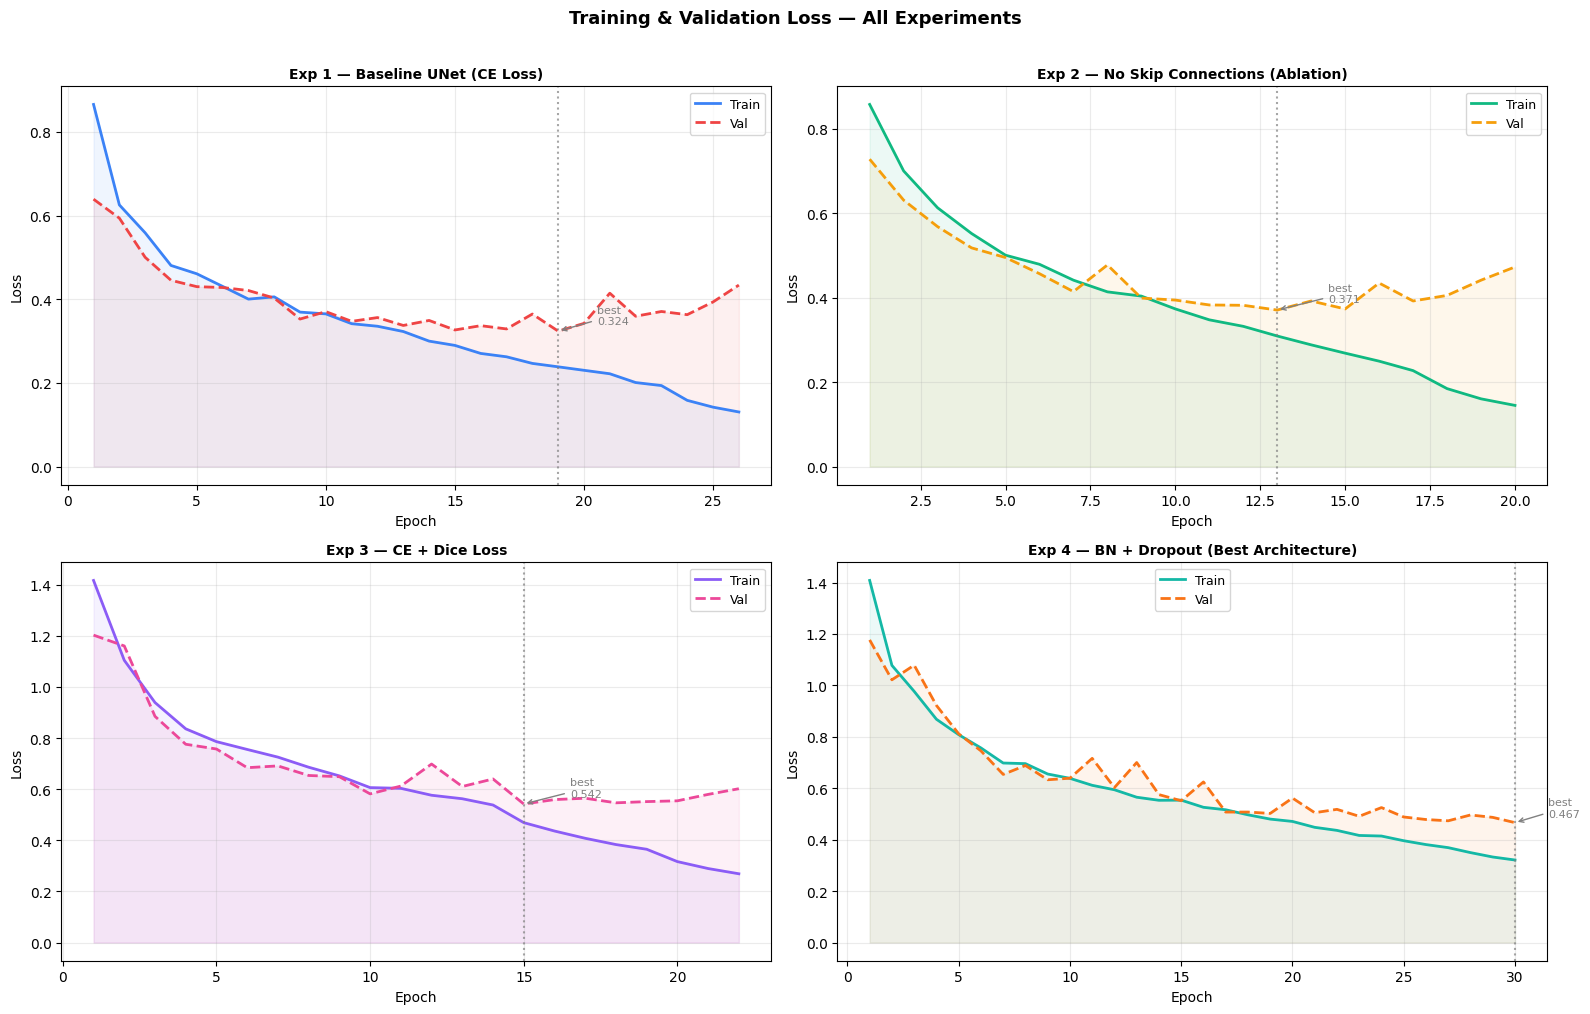

saved -> loss_curves.png


In [23]:
EXP_COLORS = [
    ("#3B82F6", "#EF4444"),
    ("#10B981", "#F59E0B"),
    ("#8B5CF6", "#EC4899"),
    ("#14B8A6", "#F97316"),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, (name, res), (c_tr, c_va) in zip(axes.flatten(), RESULTS.items(), EXP_COLORS):
    ep_x = range(1, len(res["train_loss"]) + 1)
    ax.plot(ep_x, res["train_loss"], color=c_tr, lw=2, label="Train")
    ax.plot(ep_x, res["val_loss"],   color=c_va, lw=2, label="Val", linestyle="--")
    ax.fill_between(ep_x, res["train_loss"], alpha=0.08, color=c_tr)
    ax.fill_between(ep_x, res["val_loss"],   alpha=0.08, color=c_va)

    best_ep  = int(np.argmin(res["val_loss"])) + 1
    best_val = min(res["val_loss"])
    ax.axvline(best_ep, color="gray", linestyle=":", alpha=0.7)
    ax.annotate(f"best\n{best_val:.3f}",
                xy=(best_ep, best_val), xytext=(best_ep + 1.5, best_val * 1.05),
                fontsize=8, color="gray",
                arrowprops=dict(arrowstyle="->", color="gray"))

    ax.set_title(name, fontsize=10, fontweight="bold")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.25)

plt.suptitle("Training & Validation Loss — All Experiments",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved -> loss_curves.png")

## Results Summary

In [24]:
print("\n" + "="*90)
print(f"  {'Experiment':<46}  {'Params':>10}  {'mIoU':>7}  {'Dice':>7}")
print("="*90)
for name, res in RESULTS.items():
    print(f"  {name:<46}  {res['n_params']:>10,}  {res['miou']:>7.4f}  {res['dice']:>7.4f}")
print("="*90)

print("\nPer-Class IoU:")
print(f"  {'Experiment':<46}  " + "  ".join(f"{c:>16}" for c in CLASS_NAMES))
print("-"*90)
for name, res in RESULTS.items():
    row = "  ".join(f"{res['iou_pc'][c]:>16.4f}" for c in range(NUM_CLASSES))
    print(f"  {name:<46}  {row}")


  Experiment                                          Params     mIoU     Dice
  Exp 1 — Baseline UNet (CE Loss)                 31,031,875   0.6961   0.8076
  Exp 2 — No Skip Connections (Ablation)          27,898,435   0.6595   0.7778
  Exp 3 — CE + Dice Loss                          31,031,875   0.7198   0.8254
  Exp 4 — BN + Dropout (Best Architecture)        31,037,763   0.7516   0.8483

Per-Class IoU:
  Experiment                                      Pet (Foreground)        Background            Border
------------------------------------------------------------------------------------------
  Exp 1 — Baseline UNet (CE Loss)                           0.7621            0.8683            0.4580
  Exp 2 — No Skip Connections (Ablation)                    0.7284            0.8501            0.4000
  Exp 3 — CE + Dice Loss                                    0.7864            0.8823            0.4906
  Exp 4 — BN + Dropout (Best Architecture)                  0.8193            0.9014 

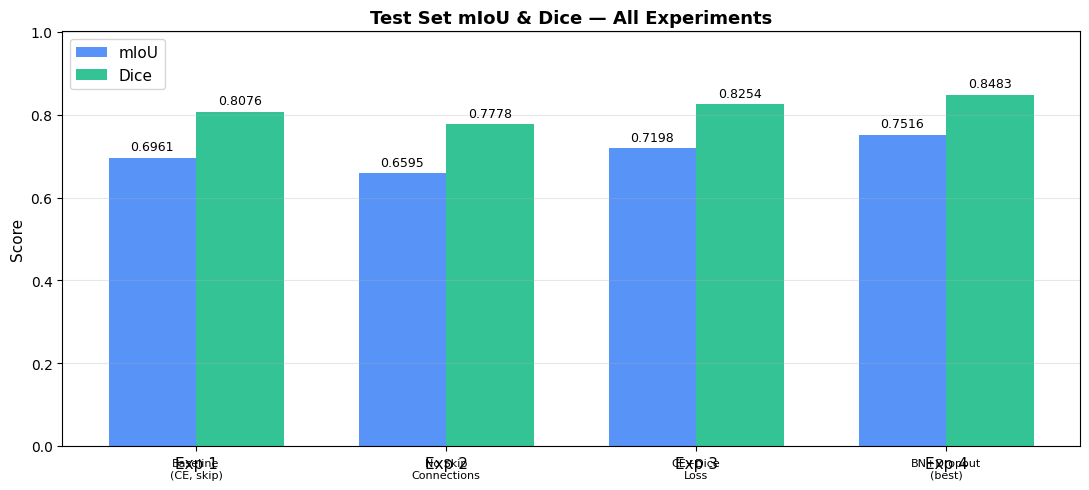

In [25]:
short_names = [f"Exp {i+1}" for i in range(len(RESULTS))]
miou_vals   = [res["miou"] for res in RESULTS.values()]
dice_vals   = [res["dice"] for res in RESULTS.values()]

x = np.arange(len(short_names))
w = 0.35
fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - w/2, miou_vals, w, label="mIoU",  color="#3B82F6", alpha=0.85)
b2 = ax.bar(x + w/2, dice_vals, w, label="Dice",  color="#10B981", alpha=0.85)
ax.bar_label(b1, fmt="%.4f", fontsize=9, padding=3)
ax.bar_label(b2, fmt="%.4f", fontsize=9, padding=3)
ax.set_xticks(x); ax.set_xticklabels(short_names, fontsize=11)
ax.set_ylim(0, max(max(miou_vals), max(dice_vals)) * 1.18)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Test Set mIoU & Dice — All Experiments", fontsize=13, fontweight="bold")
ax.legend(fontsize=11); ax.grid(axis="y", alpha=0.3)

desc = ["Baseline\n(CE, skip)", "No Skip\nConnections", "CE+Dice\nLoss", "BN+Dropout\n(best)"]
for xi, d in zip(x, desc):
    ax.text(xi, -0.03, d, ha="center", va="top", fontsize=8,
            transform=ax.get_xaxis_transform())

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/metrics_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Border Class Analysis

The border class is the minority class (~few %). Dice loss should noticeably improve it.

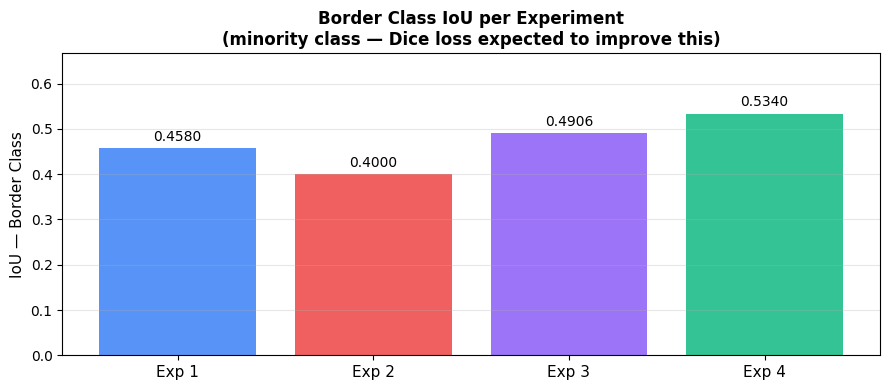

In [26]:
border_iou = [RESULTS[n]["iou_pc"][2] for n in RESULTS]

fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#3B82F6", "#EF4444", "#8B5CF6", "#10B981"]
bars = ax.bar(range(4), border_iou, color=colors, alpha=0.85)
ax.bar_label(bars, fmt="%.4f", fontsize=10, padding=3)
ax.set_xticks(range(4))
ax.set_xticklabels([f"Exp {i+1}" for i in range(4)], fontsize=11)
ax.set_ylabel("IoU — Border Class", fontsize=11)
ax.set_title("Border Class IoU per Experiment\n(minority class — Dice loss expected to improve this)",
             fontsize=12, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, max(border_iou) * 1.25)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/border_class_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## Per-Class Dice Heatmap

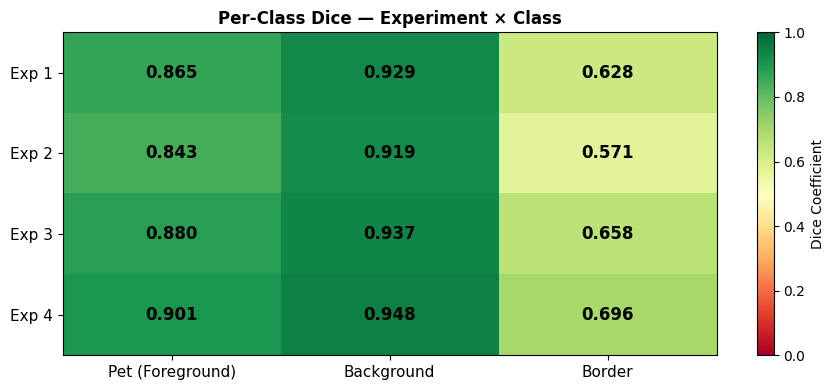

In [27]:
dice_matrix = np.array([RESULTS[n]["dice_pc"] for n in RESULTS])

fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(dice_matrix, cmap="RdYlGn", vmin=0.0, vmax=1.0, aspect="auto")
plt.colorbar(im, ax=ax, label="Dice Coefficient")

ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(CLASS_NAMES, fontsize=11)
ax.set_yticks(range(4)); ax.set_yticklabels([f"Exp {i+1}" for i in range(4)], fontsize=11)
ax.set_title("Per-Class Dice — Experiment × Class", fontsize=12, fontweight="bold")

for i in range(dice_matrix.shape[0]):
    for j in range(dice_matrix.shape[1]):
        v = dice_matrix[i, j]
        ax.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=12,
                color="black" if v > 0.5 else "white", fontweight="bold")

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/dice_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## Qualitative Comparison

Visually compare predictions from all 4 experiments on a few test images.

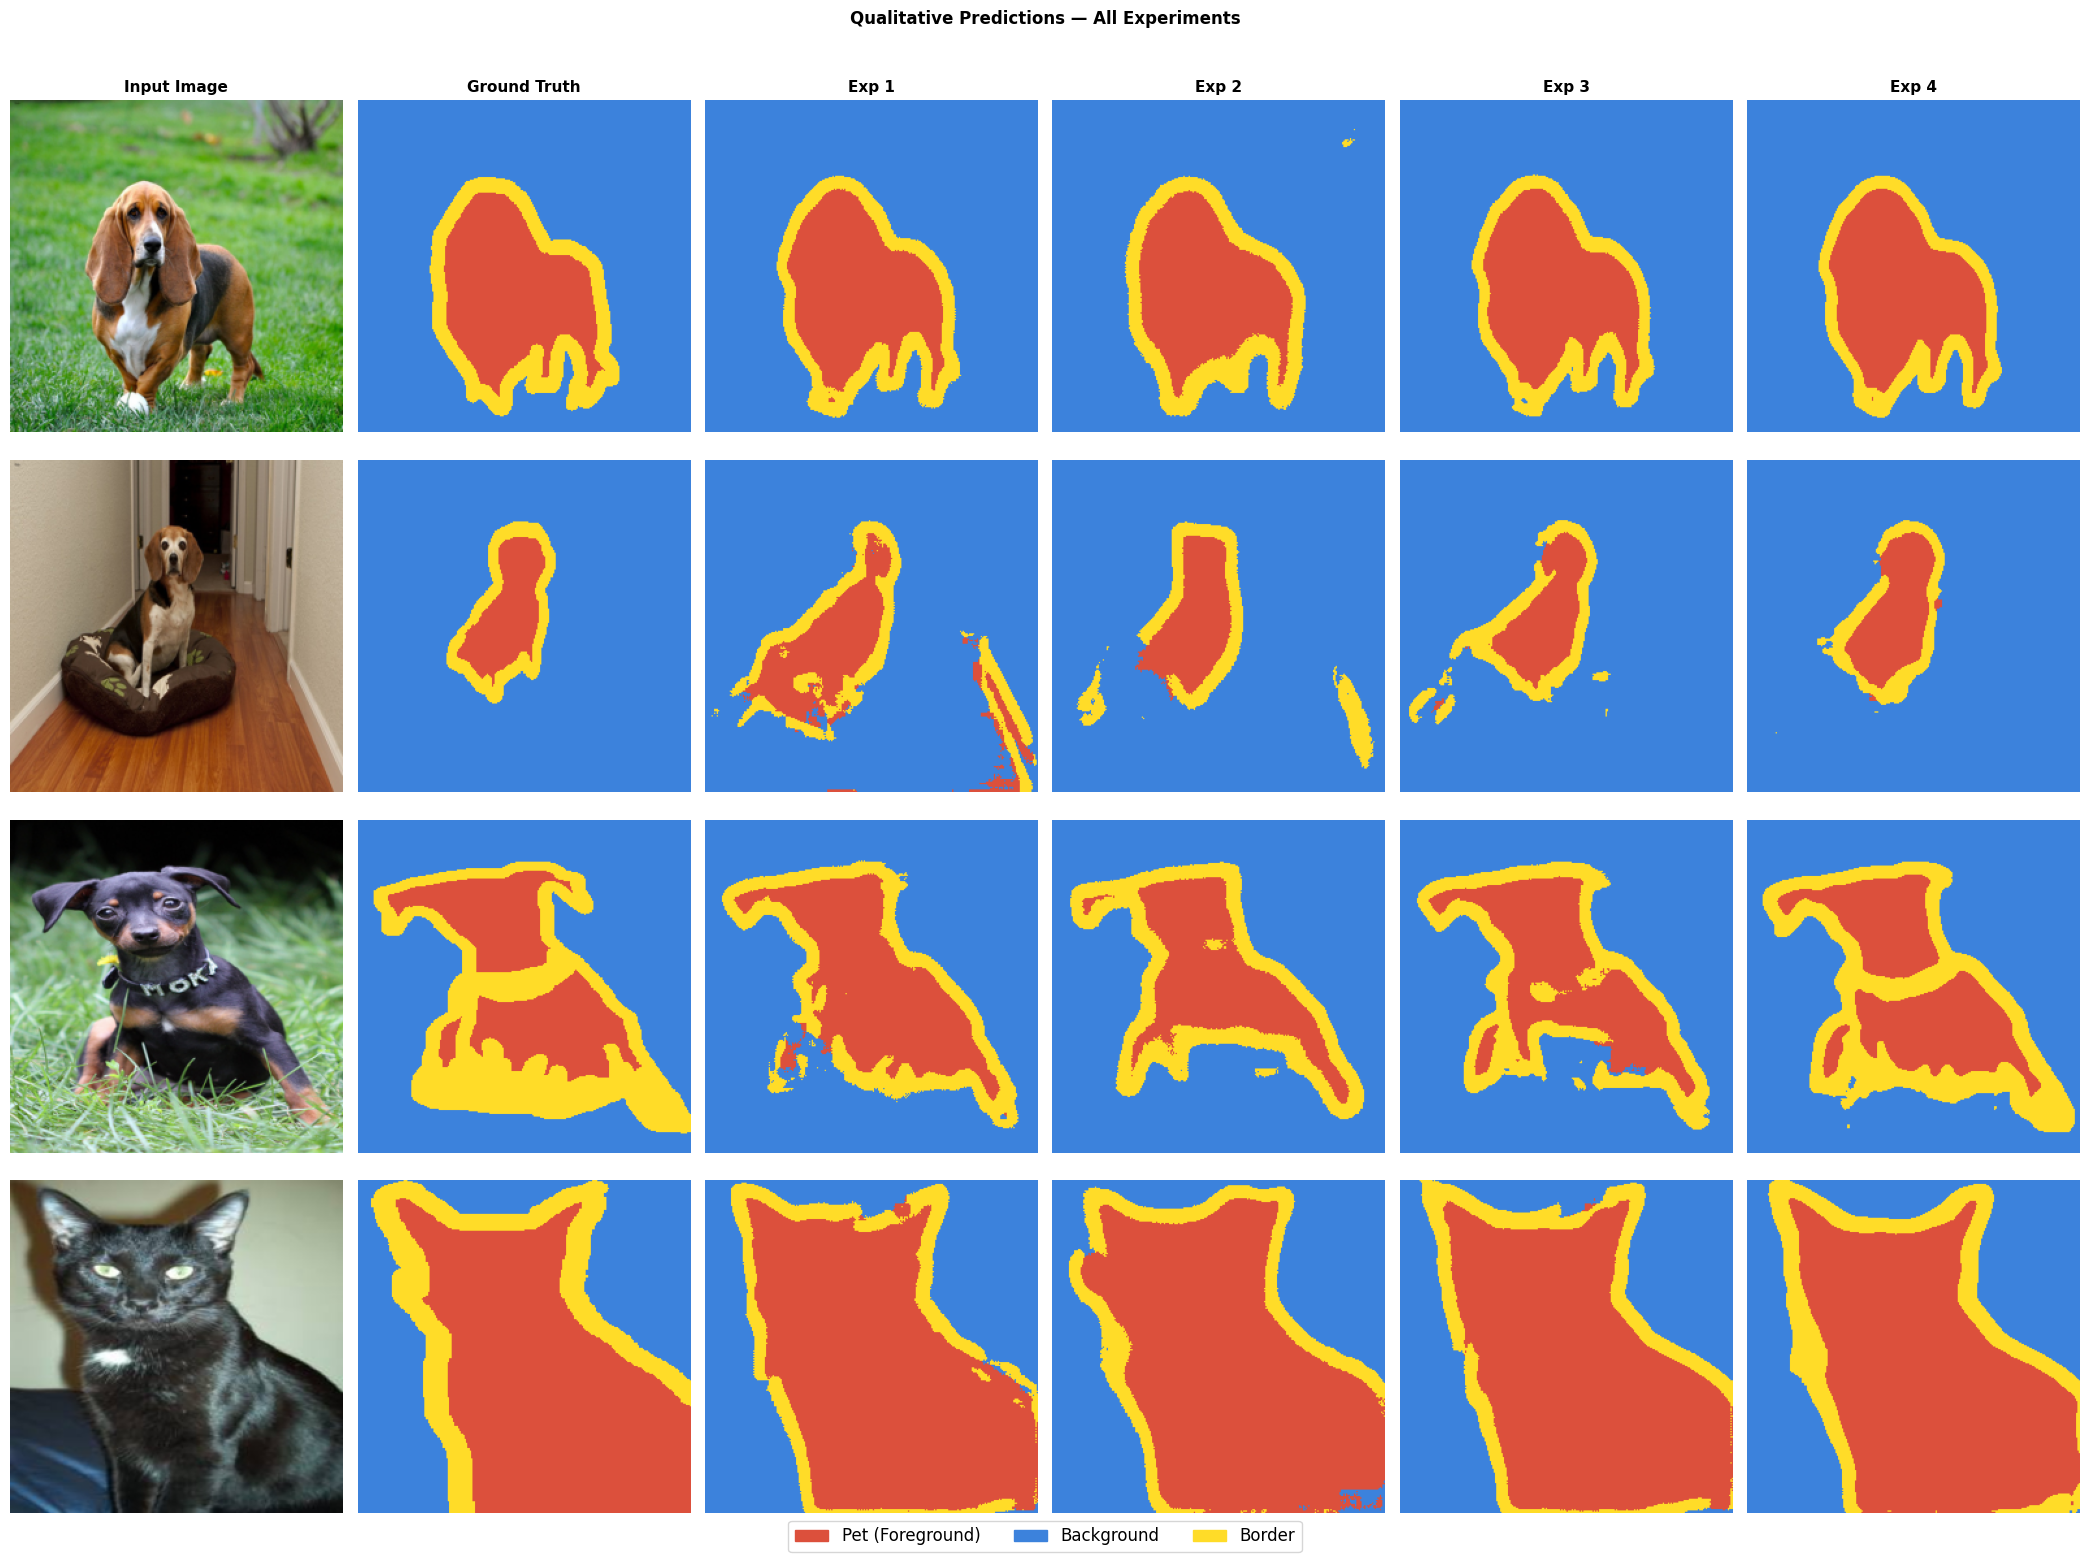

In [33]:
np.random.seed(7)
SHOW_N  = 4
indices = np.random.choice(len(test_ds), SHOW_N, replace=False)
n_cols = len(RESULTS) + 2
fig, axes = plt.subplots(SHOW_N, n_cols, figsize=(3.5 * n_cols, 3.8 * SHOW_N))
col_titles = ["Input Image", "Ground Truth"] + [f"Exp {i+1}" for i in range(len(RESULTS))]
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=11, fontweight="bold")

for row, idx in enumerate(indices):
    img, gt_mask = test_ds[idx]
    axes[row, 0].imshow(unnorm(img))
    axes[row, 1].imshow(decode_mask(gt_mask))
    axes[row, 0].set_ylabel(f"Sample {row+1}", fontsize=9)

    for col, (name, res) in enumerate(RESULTS.items(), start=2):
        exp_num = list(RESULTS.keys()).index(name) + 1
        cfg = res["cfg"]
        m = UNet(
            in_channels=3,
            num_classes=NUM_CLASSES,
            features=[64, 128, 256, 512],
            use_skip=cfg["use_skip"],
            use_bn=cfg["use_bn"],
            bottleneck_drop=cfg["bottleneck_drop"],
        ).to(DEVICE)
        ckpt_path = f"{OUT_DIR}/exp{exp_num}_best.pth"
        ckpt = torch.load(ckpt_path, map_location=DEVICE)
        m.load_state_dict(ckpt["state_dict"])  # ← checkpoint is a dict, not bare state_dict
        m.eval()
        with torch.no_grad():
            pred = m(img.unsqueeze(0).to(DEVICE)).argmax(dim=1).squeeze().cpu()
        axes[row, col].imshow(decode_mask(pred))
        m.cpu()

    for col in range(n_cols):
        axes[row, col].axis("off")

patches = [mpatches.Patch(color=CLASS_COLORS[c]/255, label=CLASS_NAMES[c])
           for c in range(NUM_CLASSES)]
fig.legend(handles=patches, loc="lower center", ncol=3, fontsize=12,
           bbox_to_anchor=(0.5, -0.01))
plt.suptitle("Qualitative Predictions — All Experiments", fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/qualitative_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

In [35]:
print("\n── Final Summary ──────────────────────────────────────────────────")
print(f"  {'Exp':<4}  {'Params':>12}  {'mIoU':>7}  {'Dice':>7}  {'Border IoU':>10}")
print("  " + "─"*50)
for i, (name, res) in enumerate(RESULTS.items(), start=1):
    print(f"  Exp {i}  {res['n_params']:>12,}  {res['miou']:>7.4f}  "
          f"{res['dice']:>7.4f}  {res['iou_pc'][2]:>10.4f}")
print()
print(f"Output files saved to {OUT_DIR}/")
print("  loss_curves.png")
print("  metrics_comparison.png")
print("  border_class_analysis.png")
print("  dice_heatmap.png")
print("  qualitative_comparison.png")
print("  exp1_best.pth, exp2_best.pth, exp3_best.pth, exp4_best.pth")
print()
print("All done.")


── Final Summary ──────────────────────────────────────────────────
  Exp         Params     mIoU     Dice  Border IoU
  ──────────────────────────────────────────────────
  Exp 1    31,031,875   0.6961   0.8076      0.4580
  Exp 2    27,898,435   0.6595   0.7778      0.4000
  Exp 3    31,031,875   0.7198   0.8254      0.4906
  Exp 4    31,037,763   0.7516   0.8483      0.5340

Output files saved to /kaggle/working/
  loss_curves.png
  metrics_comparison.png
  border_class_analysis.png
  dice_heatmap.png
  qualitative_comparison.png
  exp1_best.pth, exp2_best.pth, exp3_best.pth, exp4_best.pth

All done.
